In [6]:
# Similar to https://testtoolshed.g2.bx.psu.edu/repository/display_tool?repository_id=f305cd3c78286d17&tool_config=%2Fsrv%2Ftoolshed%2Ftest%2Fvar%2Fdata%2Frepos%2F001%2Frepo_1792%2FgeneBody_coverage.xml&changeset_revision=cd2daa987b69 
# Read coverage over gene body. This module is used to check if read coverage is uniform and if there is any 5'/3' bias. 
# This module scales all transcripts to 100 nt and calculates the number of reads covering each nucleotide position. 
# Finally, it generates plots illustrating the coverage profile along the gene body.

# If 3 or more BAM files were provided. This program generates a lineGraph and a heatmap. If fewer than 3 BAM files were provided, only lineGraph is generated. See below for examples.

# TO_DO??!
# try rolling average smoothing? averaging across neighboring bins... 

In [7]:
import os
import subprocess
import gffutils
import pandas as pd

In [8]:
# Define BAM file paths and output directory
bam_files = {
    "SS2": "/gpfs/commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/Plate_seq/3_month/170918_A00111_0060_AH3FYVDMXX__170918_A00111_0059_BH3G22DMXX/results_gencode_ercc/P9-MAA000399-3_9_M-1-1.gencode.vM19.ERCC.Aligned.out.sorted.bam",
    "EasySci": "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/RH/Cortical_projection_neurons_1_6mo_1002/Cortical_projection_neurons_1_6mo_1002_CB.bam"
}

OUT_DIR = "/gpfs/commons/projects/knowles_singlecell_splicing/deeptools"

# Ensure output directory exists
os.makedirs(OUT_DIR, exist_ok=True)

# Run bamCoverage for both SS2 and EasySci
for name, bam_file in bam_files.items():
    output_bw = os.path.join(OUT_DIR, f"{name}.bw")
    cmd = ["bamCoverage", "-b", bam_file, "-o", output_bw, "--normalizeUsing", "CPM"]
    
    print(f"▶ Running bamCoverage for {name}...")
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode == 0:
        print(f"✅ {name} BigWig created: {output_bw}")
    else:
        print(f"❌ Error running bamCoverage for {name}:\n{result.stderr}")


▶ Running bamCoverage for SS2...
✅ SS2 BigWig created: /gpfs/commons/projects/knowles_singlecell_splicing/deeptools/SS2.bw
▶ Running bamCoverage for EasySci...
✅ EasySci BigWig created: /gpfs/commons/projects/knowles_singlecell_splicing/deeptools/EasySci.bw


In [9]:
# 🔹 Specify the number of genes to sample
NUM_GENES = 15000  # Change this to any number

# 🔹 Define dataset configurations
datasets = {
    "SS2": {
        "gtf_file": "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf",
        "db_file": "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/gencode.vM19.db",
        "bed_file": "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/genes.bed",
    },
    "EasySci": {
        "gtf_file": "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/genome_files/gencode.vM27.basic.annotation.gtf",
        "db_file": "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/genome_files/gencode_vM27.db",
        "bed_file": "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/EasySci_genes.bed",
    },
}

# 🔹 Process each dataset
for name, paths in datasets.items():
    print(f"▶ Processing {name}...")

    gtf_file = paths["gtf_file"]
    db_file = paths["db_file"]
    bed_file = paths["bed_file"]

    # Step 1: Create or load the GTF database
    try:
        db = gffutils.FeatureDB(db_file, keep_order=True)
        print(f"✔ Loaded existing gffutils database for {name}.")
    except:
        print(f"⏳ Creating a new gffutils database for {name}...")
        db = gffutils.create_db(gtf_file, dbfn=db_file, force=True, keep_order=True, disable_infer_transcripts=True, disable_infer_genes=True)

    # Step 2: Extract gene features and convert to BED format
    bed_data = []
    for gene in db.features_of_type("gene"):
        chrom = gene.chrom
        start = gene.start - 1  # Convert GTF 1-based to BED 0-based
        end = gene.end
        gene_id = gene.attributes.get("gene_id", ["unknown"])[0]  # Extract gene_id safely
        bed_data.append([chrom, start, end, gene_id])

    # Convert to DataFrame
    bed_df = pd.DataFrame(bed_data, columns=["chrom", "start", "end", "gene_id"])

    # Step 3: Sample specified number of genes (if dataset is large)
    if len(bed_df) > NUM_GENES:
        bed_df = bed_df.sample(NUM_GENES, random_state=42)  # Fix random seed for reproducibility

    # Step 4: Save BED file
    bed_df.to_csv(bed_file, sep="\t", index=False, header=False)
    
    print(f"✅ {name} GTF converted to BED: {bed_file} ({bed_df.shape[0]} genes saved)\n")

▶ Processing SS2...
✔ Loaded existing gffutils database for SS2.
✅ SS2 GTF converted to BED: /gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/genes.bed (15000 genes saved)

▶ Processing EasySci...
✔ Loaded existing gffutils database for EasySci.
✅ EasySci GTF converted to BED: /gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/EasySci_genes.bed (15000 genes saved)



In [10]:
# Define input files for each dataset
datasets = {
    "SS2": {
        "bw_file": "/gpfs/commons/projects/knowles_singlecell_splicing/deeptools/SS2.bw",
        "bed_file": "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/genes.bed",
        "matrix_file": "/gpfs/commons/projects/knowles_singlecell_splicing/deeptools/SS2_matrix.gz",
        "matrix_txt": "/gpfs/commons/projects/knowles_singlecell_splicing/deeptools/SS2_matrix.txt",
    },
    "EasySci": {
        "bw_file": "/gpfs/commons/projects/knowles_singlecell_splicing/deeptools/EasySci.bw",
        "bed_file": "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/EasySci_genes.bed",
        "matrix_file": "/gpfs/commons/projects/knowles_singlecell_splicing/deeptools/EasySci_matrix.gz",
        "matrix_txt": "/gpfs/commons/projects/knowles_singlecell_splicing/deeptools/EasySci_matrix.txt",
    },
}

# Run computeMatrix for each dataset
for name, paths in datasets.items():
    print(f"▶ Running computeMatrix for {name}...")

    cmd = [
        "computeMatrix", "scale-regions",
        "-S", paths["bw_file"],
        "-R", paths["bed_file"],
        "--regionBodyLength", "1000",
        "--beforeRegionStartLength", "0",
        "--afterRegionStartLength", "0",
        "--skipZeros",
        "-o", paths["matrix_file"],
        "--outFileNameMatrix", paths["matrix_txt"]
    ]

    # Run computeMatrix
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode == 0:
        print(f"✅ computeMatrix completed for {name}: {paths['matrix_file']}")
    else:
        print(f"❌ Error running computeMatrix for {name}:\n{result.stderr}")


▶ Running computeMatrix for SS2...
✅ computeMatrix completed for SS2: /gpfs/commons/projects/knowles_singlecell_splicing/deeptools/SS2_matrix.gz
▶ Running computeMatrix for EasySci...
✅ computeMatrix completed for EasySci: /gpfs/commons/projects/knowles_singlecell_splicing/deeptools/EasySci_matrix.gz


▶ Plotting coverage profile for SS2...
✅ SS2 profile plot saved: /gpfs/commons/projects/knowles_singlecell_splicing/deeptools/SS2_profile.png
▶ Plotting coverage profile for EasySci...
✅ EasySci profile plot saved: /gpfs/commons/projects/knowles_singlecell_splicing/deeptools/EasySci_profile.png

🖼️ SS2 Coverage Profile:


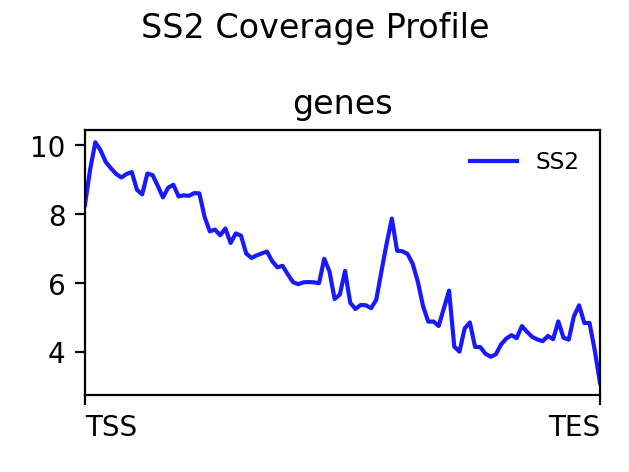


🖼️ EasySci Coverage Profile:


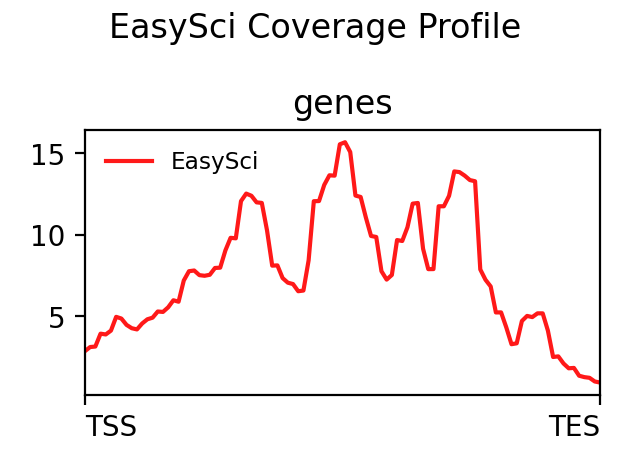

In [11]:
import os
import subprocess
from IPython.display import Image, display

# Define input files, output paths, and colors for each dataset
datasets = {
    "SS2": {
        "matrix_file": "/gpfs/commons/projects/knowles_singlecell_splicing/deeptools/SS2_matrix.gz",
        "profile_plot": "/gpfs/commons/projects/knowles_singlecell_splicing/deeptools/SS2_profile.png",
        "color": "blue",
    },
    "EasySci": {
        "matrix_file": "/gpfs/commons/projects/knowles_singlecell_splicing/deeptools/EasySci_matrix.gz",
        "profile_plot": "/gpfs/commons/projects/knowles_singlecell_splicing/deeptools/EasySci_profile.png",
        "color": "red",
    },
}

# Run plotProfile for each dataset
for name, paths in datasets.items():
    print(f"▶ Plotting coverage profile for {name}...")

    cmd_profile = [
        "plotProfile", "-m", paths["matrix_file"],
        "-out", paths["profile_plot"],
        "--perGroup",
        "--plotTitle", f"{name} Coverage Profile",
        "--plotHeight", "6", "--plotWidth", "8",
        "--colors", paths["color"]
    ]
    
    result_profile = subprocess.run(cmd_profile, capture_output=True, text=True)
    
    if result_profile.returncode == 0:
        print(f"✅ {name} profile plot saved: {paths['profile_plot']}")
    else:
        print(f"❌ Error in profile plot for {name}:\n{result_profile.stderr}")

# Display the plots in Jupyter Notebook
for name, paths in datasets.items():
    print(f"\n🖼️ {name} Coverage Profile:")
    display(Image(paths["profile_plot"]))

In [23]:
import gffutils
import pandas as pd
from collections import defaultdict

# 🔹 Specify the number of genes to sample
NUM_GENES = 10000  # Change this to any number

# 🔹 Define dataset configurations
datasets = {
    "SS2": {
        "gtf_file": "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf",
        "db_file": "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/gencode.vM19.db",
        "bed_file": "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/genes.bed",
    },
    "EasySci": {
        "gtf_file": "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/genome_files/gencode.vM27.basic.annotation.gtf",
        "db_file": "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/genome_files/gencode_vM27.db",
        "bed_file": "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/EasySci_genes.bed",
    },
}

# 🔹 Process each dataset
for name, paths in datasets.items():
    print(f"▶ Processing {name}...")

    gtf_file = paths["gtf_file"]
    db_file = paths["db_file"]
    bed_file = paths["bed_file"]

    # Step 1: Create or load the GTF database
    try:
        db = gffutils.FeatureDB(db_file, keep_order=True)
        print(f"✔ Loaded existing gffutils database for {name}.")
    except:
        print(f"⏳ Creating a new gffutils database for {name}...")
        db = gffutils.create_db(gtf_file, dbfn=db_file, force=True, keep_order=True, disable_infer_transcripts=True, disable_infer_genes=True)

    # Step 2: Extract gene features and exon information
    bed_data = []
    gene_exons = defaultdict(list)

    for exon in db.features_of_type("exon"):
        gene_id = exon.attributes.get("gene_id", ["unknown"])[0]
        gene_exons[gene_id].append((exon.start - 1, exon.end))  # Convert to 0-based

    for gene in db.features_of_type("gene"):
        chrom = gene.chrom
        start = gene.start - 1  # Convert GTF 1-based to BED 0-based
        end = gene.end
        gene_id = gene.attributes.get("gene_id", ["unknown"])[0]
        strand = gene.strand

        # Ensure exons exist for this gene
        if gene_id in gene_exons:
            exons = sorted(gene_exons[gene_id])

            # Compute BED12-specific fields
            thickStart = start  # Usually, thickStart = start (if CDS not available)
            thickEnd = end  # Usually, thickEnd = end (if CDS not available)
            itemRgb = "0,0,0"  # Default black color
            blockCount = len(exons)
            blockSizes = ",".join(str(e[1] - e[0]) for e in exons)
            blockStarts = ",".join(str(e[0] - start) for e in exons)

            # Add BED12 entry
            bed_data.append([chrom, start, end, gene_id, 0, strand, thickStart, thickEnd, itemRgb, blockCount, blockSizes, blockStarts])

    # Convert to DataFrame
    bed_df = pd.DataFrame(bed_data, columns=["chrom", "start", "end", "gene_id", "score", "strand", "thickStart", "thickEnd", "itemRgb", "blockCount", "blockSizes", "blockStarts"])

    # Step 3: Sample specified number of genes (if dataset is large)
    if len(bed_df) > NUM_GENES:
        bed_df = bed_df.sample(NUM_GENES, random_state=42)  # Fix random seed for reproducibility

    # Step 4: Save BED12 file
    bed_df.to_csv(bed_file, sep="\t", index=False, header=False)

    print(f"✅ {name} GTF converted to BED12: {bed_file} ({bed_df.shape[0]} genes saved)\n")


▶ Processing SS2...
✔ Loaded existing gffutils database for SS2.
✅ SS2 GTF converted to BED12: /gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/genes.bed (10000 genes saved)

▶ Processing EasySci...
✔ Loaded existing gffutils database for EasySci.
✅ EasySci GTF converted to BED12: /gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/EasySci_genes.bed (10000 genes saved)



In [24]:
!geneBody_coverage.py -r /gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/genes.bed -i /gpfs/commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/Plate_seq/3_month/170918_A00111_0060_AH3FYVDMXX__170918_A00111_0059_BH3G22DMXX/results_gencode_ercc/P9-MAA000399-3_9_M-1-1.gencode.vM19.ERCC.Aligned.out.sorted.bam,/gpfs/commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/Plate_seq/24_month/180918_A00111_0213_BHGKTWDMXX/results_gencode_ercc/P9_B003905_S273.gencode.vM19.ERCC.Aligned.out.sorted.bam,/gpfs/commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/10x/10x/3_month/10X_P8_12/possorted_genome_bam.bam  -o TMS_PLOT

@ 2025-02-24 23:14:45: Read BED file (reference gene model) ...
@ 2025-02-24 23:14:46: Total 10000 transcripts loaded
@ 2025-02-24 23:14:46: Get BAM file(s) ...
	/gpfs/commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/Plate_seq/3_month/170918_A00111_0060_AH3FYVDMXX__170918_A00111_0059_BH3G22DMXX/results_gencode_ercc/P9-MAA000399-3_9_M-1-1.gencode.vM19.ERCC.Aligned.out.sorted.bam
	/gpfs/commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/Plate_seq/24_month/180918_A00111_0213_BHGKTWDMXX/results_gencode_ercc/P9_B003905_S273.gencode.vM19.ERCC.Aligned.out.sorted.bam
	/gpfs/commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/10x/10x/3_month/10X_P8_12/possorted_genome_bam.bam
@ 2025-02-24 23:14:46: Processing P9-MAA000399-3_9_M-1-1.gencode.vM19.ERCC.Aligned.out.sorted.bam ...
 100 transcripts finished	200 transcripts finished	300 transcripts finished	400 transcripts finished	500 transcripts finished	600 transcripts finished	700 transcripts finished	

In [25]:
!geneBody_coverage.py -r /gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/EasySci_genes.bed  -i /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/RH/Cortical_projection_neurons_1_6mo_1002/Cortical_projection_neurons_1_6mo_1002_CB.bam,/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/RH/Interbrain_and_midbrain_neurons_2_APOE4_TREM2_307/Interbrain_and_midbrain_neurons_2_APOE4_TREM2_307_CB.bam,/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/RH/Oligodendrocytes_6mo_1484/Oligodendrocytes_6mo_1484_CB.bam  -o EasySCI_PLOT

@ 2025-02-24 23:35:36: Read BED file (reference gene model) ...
@ 2025-02-24 23:35:37: Total 10000 transcripts loaded
@ 2025-02-24 23:35:37: Get BAM file(s) ...
	/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/RH/Cortical_projection_neurons_1_6mo_1002/Cortical_projection_neurons_1_6mo_1002_CB.bam
	/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/RH/Interbrain_and_midbrain_neurons_2_APOE4_TREM2_307/Interbrain_and_midbrain_neurons_2_APOE4_TREM2_307_CB.bam
	/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/RH/Oligodendrocytes_6mo_1484/Oligodendrocytes_6mo_1484_CB.bam
@ 2025-02-24 23:35:37: Processing Cortical_projection_neurons_1_6mo_1002_CB.bam ...
 100 transcripts finished	200 transcripts finished	300 transcripts finished	400 transcripts finished	500 transcripts finished	600 transcripts finished	700 transcripts finished	800 transcripts finished	900 transcripts fi

 7500 transcripts finished	7600 transcripts finished	7700 transcripts finished	7800 transcripts finished	7900 transcripts finished	8000 transcripts finished	8100 transcripts finished	8200 transcripts finished	8300 transcripts finished	8400 transcripts finished	8500 transcripts finished	8600 transcripts finished	8700 transcripts finished	8800 transcripts finished	8900 transcripts finished	9000 transcripts finished	9100 transcripts finished	9200 transcripts finished	9300 transcripts finished	9400 transcripts finished	9500 transcripts finished@ 2025-02-24 23:36:33: Processing Interbrain_and_midbrain_neurons_2_APOE4_TREM2_307_CB.bam ...
 100 transcripts finished	200 transcripts finished	300 transcripts finished	400 transcripts finished	500 transcripts finished	600 transcripts finished	700 transcripts finished	800 transcripts finished	900 transcripts finished	1000 transcripts finished	1100 transcripts finished	1200 transcripts finished	1300 transcripts finished	1400 transcripts finished	150